# 13) Çarpıklık Nedir?
Çarpıklık (Skewness), bir veri kümesindeki verilerin dağılımının simetrik olmayıp bir tarafa doğru dengesiz bir şekilde yığılması durumudur.

### Çarpıklık Türleri
- **Simetrik Dağılım**: Çarpıklık değeri sıfırdır. Veri kümesindeki elemanların dağılımı simetrik bir görüntü çizer. Bu dağılımda, ortalama = mod = medyan şeklindedir.
- **Sağa Çarpık (Pozitif Çarpık) Dağılım**: Çarpıklık değeri > 0'dır. Verinin kuyruğu sağ tarafa uzanır.Genellikle ortalama > medyan > mod şeklindedir. Veri setindeki uç değerler ortalamayı olduğundan büyük gösterir. 
- **Sola Çarpık (Negatif Çarpık) Dağılım**: Çarpıklık değeri < 0'dır. Verinin kuyruğu sol tarafa uzanır.Genellikle mod > medyan > ortalama şeklindedir. Veri setindeki uç değerler ortalamayı olduğundan küçük gösterir. 

Çarpık bir dağılım, makine öğrenmesi modellerinin performansını etkileyebilir aynı zamanda bu dağılım bazı test istatistiklerinin varsayımlarını karşılamadığından bu test istatistiklerinin sonucu yanıltıcı olabilir.

Çarpık bir dağılımı düzeltmek için bazı dönüşümler kullanılabilir.
### Uygulanabilecek Bazı Dönüşümler

1. Sağa Çarpık (Pozitif Çarpık) Dağılımlar İçin
- Sağa çarpık dağılımlarda sağ tarafta uzun bir kuyruk ve uç değerler (çok büyük sayılar) bulunur. Amaç, bu büyük değerleri küçülterek merkeze yaklaştırmaktır.
- Logaritmik Dönüşüm log(x) veya ln(x): En yaygın kullanılan yöntemdir. Orta ve yüksek dereceli sağa çarpıklıkları düzeltmede çok etkilidir. Veride 0 varsa log(x + 1) kullanılır.
- Karekök Dönüşümü sqrt{x}: Hafif dereceli sağa çarpıklıklar için idealdir. Logaritma kadar sert bir düzeltme yapmaz. Veride 0 varsa sqrt{x+0.5} tercih edilebilir.
- Küp Kök Dönüşümü sqrt[3]{x}: Orta dereceli çarpıklıklarda kullanılır. Karekökten daha güçlü, logaritmadan daha hafiftir. Negatif değer içeren verilere de doğrudan uygulanabilmesi en büyük avantajıdır.
- Ters (Yansıtıcı) Dönüşüm 1 / x: Çok şiddetli sağa çarpıklıkları düzeltmek için kullanılan en sert dönüşümdür. Küçük değerleri büyütür, büyük değerleri çok küçültür. Verilerin sıralamasını tersine çevirdiği için yorumlarken dikkat edilmelidir.

2. Sola Çarpık (Negatif Çarpık) Dağılımlar İçin
- Sola çarpık dağılımlarda sol tarafta küçük değerlerden oluşan uzun bir kuyruk vardır. Bu dağılımları düzeltmek için iki farklı strateji izlenir:
- Yansıtma Yöntemi (Önerilen)
Sola çarpık veri önce tersine çevrilerek sağa çarpık hale getirilir, ardından yukarıdaki sağa çarpık dönüşümleri uygulanır.
Formül: x_{yeni} = (K + 1) - x
- (Buradaki K, veri kümesindeki en büyük değerdir. Bu işlemden sonra veriye Logaritma veya Karekök uygulanır).
- Doğrudan Üstel Dönüşümler
- Yansıtma yapmak istenmiyorsa, verilerin üssü alınarak sol kuyruktaki küçük değerler birbirinden uzaklaştırılır.
- Kare Dönüşümü x^{2}: Hafif sola çarpık dağılımları düzeltmek için verilerin karesi alınır.
- Küp Dönüşümü x^{3}: Orta ve şiddetli sola çarpık dağılımlarda verilerin küpü alınır.

3. Otomatik ve İleri Düzey Dönüşümler
- Deneme yanılma yapmak yerine, veriye en uygun dönüşümü matematiksel olarak hesaplayan gelişmiş yöntemler de mevcuttur:
- Box-Cox Dönüşümü: Sadece pozitif değerler içeren verilerde çalışır. Veriyi normal dağılıma en yakın hale getirecek ideal lambda  (lambda) katsayısını otomatik bulur. lambda=0 ise logaritma, lambda=0.5 ise karekök uygular.
- Yeo-Johnson Dönüşümü: Box-Cox yöntemine benzer ancak sıfır ve negatif değer içeren veri kümelerinde de sorunsuz çalışır. Modern veri analizinde sıkça tercih edilir.

In [3]:
from scipy.stats import skew # Çarpıklık hesabı için SciPy kütüphanesinden stats modülünün içinden skew fonksiyonunu import ediyoruz.
veri = [10,20,30,40,50,60,70,80,90,100]
print(f"Veri setinin çarpıklık değeri:{skew(veri)}")

Veri setinin çarpıklık değeri:0.0


Yukarıdaki örnekteki veri kümesinin çarpıklık değeri 0 çıktı. Bu da verinin **simetrik** bir dağılıma sahip olduğunu gösterir. Ancak bu, 
verinin mutlaka normal dağılım olduğu anlamına gelmez, normal dağılım olabilmesi için ayrıca kurtosis değerinin de normale yakın olması gerekir.

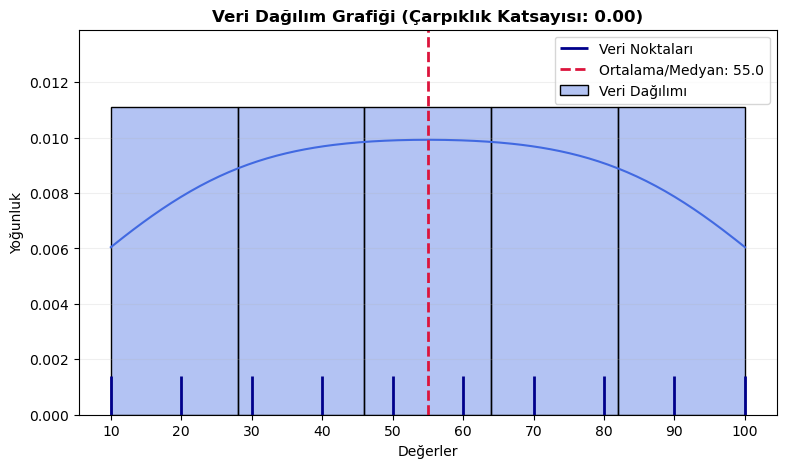

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
carpiklik = skew(veri)
ortalama = np.mean(veri)

# 2. Grafik Alanını Oluşturma
plt.figure(figsize=(9, 5))

# Histogram, Yoğunluk Eğrisi (KDE) ve Veri Noktaları (Rug)
sns.histplot(veri, kde=True, bins=5, color="royalblue", stat="density", alpha=0.4, label="Veri Dağılımı")
sns.rugplot(veri, color="darkblue", height=0.1, linewidth=2, label="Veri Noktaları")

# Tam Orta Noktaya (Ortalama/Medyan) Kesikli Çizgi Ekleme
plt.axvline(ortalama, color="crimson", linestyle="--", linewidth=2, label=f"Ortalama/Medyan: {ortalama}")

# Grafik Süslemeleri ve Bilgiler
plt.title(f"Veri Dağılım Grafiği (Çarpıklık Katsayısı: {carpiklik:.2f})", fontsize=12, fontweight='bold')
plt.xlabel("Değerler")
plt.ylabel("Yoğunluk")
plt.xticks(veri) # Eksen üzerinde tüm veri noktalarını gösterir
plt.legend()
plt.grid(axis='y', alpha=0.2)

# Grafik Gösterimi
plt.show()